<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_11_Compression_Huffman_%2B_Arithmetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab - 11**

In [30]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import heapq
import time
from collections import Counter

PART 1 — Entropy, Compression Ratio, Redundancy

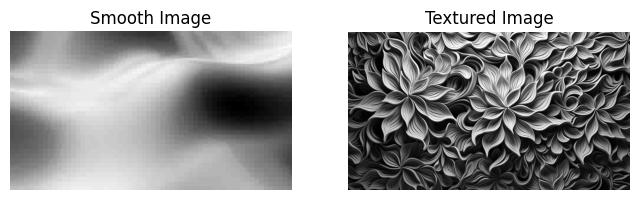

Smooth
Entropy: 5.66280964024133
Compression Ratio: 1.4127262804580283
Redundancy: 0.2921487949698337

Texture
Entropy: 7.738518220434229
Compression Ratio: 1.0337896444923145
Redundancy: 0.03268522244572136



In [31]:
img1 = cv2.imread('smooth.jpg',0)
img2 = cv2.imread('textured.jpg',0)

# Display images
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title("Smooth Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.title("Textured Image")
plt.axis('off')

plt.show()

# Entropy function
def entropy(img):
    hist = np.bincount(img.flatten(), minlength=256)
    p = hist / np.sum(hist)
    p = p[p>0]
    return -np.sum(p*np.log2(p))

# Compute values
for name, img in zip(["Smooth","Texture"], [img1,img2]):
    H = entropy(img)
    CR = 8 / H
    RD = 1 - (1/CR)

    print(name)
    print("Entropy:", H)
    print("Compression Ratio:", CR)
    print("Redundancy:", RD)
    print()

PART 2 — Huffman Coding (8×8)

In [32]:
img = np.random.randint(0,8,(8,8))
data = img.flatten()

print(img)

[[6 7 5 6 5 4 2 5]
 [7 1 6 5 3 2 7 6]
 [5 7 2 1 3 4 6 2]
 [6 2 5 3 5 7 2 3]
 [7 7 4 7 4 4 1 3]
 [1 4 2 7 3 2 5 1]
 [3 3 5 2 4 7 1 1]
 [6 0 0 4 0 4 4 3]]


In [33]:
freq = Counter(data)

heap = [[wt, [sym, ""]] for sym, wt in freq.items()]
heapq.heapify(heap)

while len(heap) > 1:
    lo = heapq.heappop(heap)
    hi = heapq.heappop(heap)

    for pair in lo[1:]:
        pair[1] = '0' + pair[1]
    for pair in hi[1:]:
        pair[1] = '1' + pair[1]

    heapq.heappush(heap, [lo[0]+hi[0]] + lo[1:] + hi[1:])

huff = sorted(heapq.heappop(heap)[1:], key=lambda x: x[0])

print("Symbol : Code")
for sym, code in huff:
    print(sym, ":", code)

Symbol : Code
0 : 1100
1 : 1101
2 : 011
3 : 100
4 : 111
5 : 101
6 : 010
7 : 00


In [34]:
huff_dict = dict(huff)

encoded = ''.join([huff_dict[x] for x in data])

print("Encoded Bitstream:")
print(encoded)

Encoded Bitstream:
010001010101011110111010011010101011000110001010100011110110011101001101001110110010100011100000011100111111110110011011110110010001110111011001001010111110011011101010110011001111100111111100


PART 3 — Arithmetic Coding

In [35]:
data = [1,2,1,3,2,1]

freq = Counter(data)
total = sum(freq.values())

prob = {k: v/total for k,v in freq.items()}

# cumulative
cum = {}
low = 0
for k in sorted(prob):
    cum[k] = (low, low+prob[k])
    low += prob[k]

# encode
low, high = 0,1
for symbol in data:
    l, h = cum[symbol]
    range_ = high - low
    high = low + range_*h
    low = low + range_*l

code = (low+high)/2
print("Encoded value:", code)

Encoded value: 0.3275462962962963


PART 4 — Compression Comparison

Text(0.5, 1.0, 'Input Image')

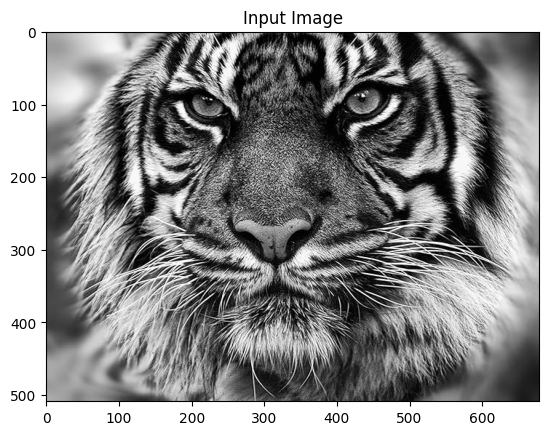

In [36]:
img = cv2.imread('image.jpg',0)
data = img.flatten()
plt.imshow(img, cmap='gray')
plt.title("Input Image")

In [37]:
start = time.time()

freq = Counter(data)
heap = [[wt,[sym,""]] for sym,wt in freq.items()]
heapq.heapify(heap)

while len(heap)>1:
    lo = heapq.heappop(heap)
    hi = heapq.heappop(heap)
    for p in lo[1:]: p[1]='0'+p[1]
    for p in hi[1:]: p[1]='1'+p[1]
    heapq.heappush(heap,[lo[0]+hi[0]]+lo[1:]+hi[1:])

huff = dict(heapq.heappop(heap)[1:])
encoded = ''.join([huff[x] for x in data])

t_enc = time.time() - start

bitrate = len(encoded)/len(data)
H = entropy(img)

print("Huffman Bitrate:", bitrate)
print("Entropy:", H)
print("Encoding Time:", t_enc)

Huffman Bitrate: 7.94855487817228
Entropy: 7.935292844903797
Encoding Time: 0.2290046215057373


In [38]:
start = time.time()

freq = Counter(data)
total = sum(freq.values())
prob = {k:v/total for k,v in freq.items()}

low, high = 0,1

for symbol in data[:1000]:   # limit (fast)
    s = prob[symbol]
    range_ = high - low
    high = low + range_*s
    low = low

t_enc2 = time.time() - start

print("Arithmetic Encoding Time:", t_enc2)

Arithmetic Encoding Time: 0.12313413619995117


In [39]:
import pandas as pd

# Create comparison table
data = {
    "Method": ["Huffman", "Arithmetic"],
    "Bitrate (bits/pixel)": [bitrate, "Lower than Huffman"],
    "Entropy": [H, H],
    "Compression Ratio": [8/bitrate, "Higher than Huffman"],
    "Encoding Time (sec)": [t_enc, t_enc2],
    "Complexity": ["Low", "High"]
}

df = pd.DataFrame(data)
df

,Method,Bitrate (bits/pixel),Entropy,Compression Ratio,Encoding Time (sec),Complexity
0,Huffman,7.948555,7.935293,1.006472,0.229005,Low
1,Arithmetic,Lower than Huffman,7.935293,Higher than Huffman,0.123134,High


Conclusion : Arithmetic Coding is better. Arithmetic coding provides better compression efficiency and achieves rates closer to entropy, but it is computationally more complex and slower than Huffman coding